In [1]:
import samplers
%cd "C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4"

C:\Users\asmaa\Desktop\Amr\Master's Thesis v0.4


C:\Users\asmaa\PycharmProjects\pythonProject\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import torch

In [3]:
# parameters
lambd = 1.55
# wave number and normalized spacing
k_0 = 2 * np.pi / lambd

In [4]:
save_folder_path = r"C:\Users\asmaa\Desktop\Amr\2nd Paper\Experiments"

In [5]:
EIs_FD_1_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode Weakly Guiding\Convergence\EIs_FD.npy")
EIs_DCNN_1_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode Weakly Guiding\Convergence\EIs_DCNN.npy")

EIs_FD_2_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode Moderate Contrast\Convergence\EIs_FD.npy")
EIs_DCNN_2_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode Moderate Contrast\Convergence\EIs_DCNN.npy")

EIs_FD_3_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode High Contrast\Convergence\EIs_FD.npy")
EIs_DCNN_3_TE = np.load(save_folder_path + r"\TE\NonPlanar\Single Mode High Contrast\Convergence\EIs_DCNN.npy")

EIs_FD_1_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode Weakly Guiding\Convergence\EIs_FD.npy")
EIs_DCNN_1_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode Weakly Guiding\Convergence\EIs_DCNN.npy")

EIs_FD_2_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode Moderate Contrast\Convergence\EIs_FD.npy")
EIs_DCNN_2_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode Moderate Contrast\Convergence\EIs_DCNN.npy")

EIs_FD_3_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode High Contrast\Convergence\EIs_FD.npy")
EIs_DCNN_3_TM = np.load(save_folder_path + r"\TM\NonPlanar\Single Mode High Contrast\Convergence\EIs_DCNN.npy")

In [6]:
font = {
    'weight' : 'bold',
    'size' : 14
    }

matplotlib.rc('font', **font)

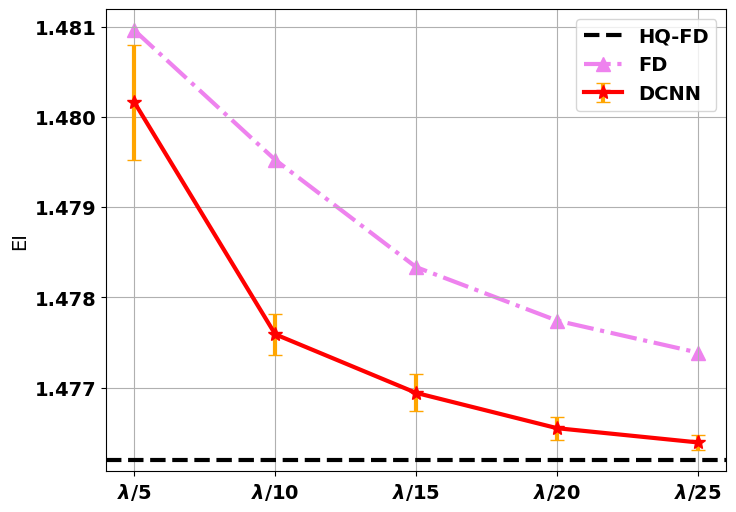

In [9]:
plt.figure(figsize=(8, 6))
plt.errorbar(np.arange(len(EIs_FD_1_TE[:5])), EIs_FD_1_TE[:5], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot', zorder=1)
plt.errorbar(np.arange(len(EIs_DCNN_1_TE)), EIs_DCNN_1_TE.mean(axis=1)[:, 0], label='DCNN', color='red', linewidth=3, marker='*', markersize=10,  yerr=EIs_DCNN_1_TE.std(axis=1)[:, 0], ecolor='orange', capsize=5, zorder=2)
plt.axhline(EIs_FD_1_TE[-1], color='black', linestyle='dashed', linewidth=3, label='HQ-FD')
plt.xticks([0, 1, 2, 3 ,4], [r'$\lambda$/5', r'$\lambda$/10', r'$\lambda$/15', r'$\lambda$/20', r'$\lambda$/25'])
plt.ylabel('EI')
plt.legend();
plt.grid(True)

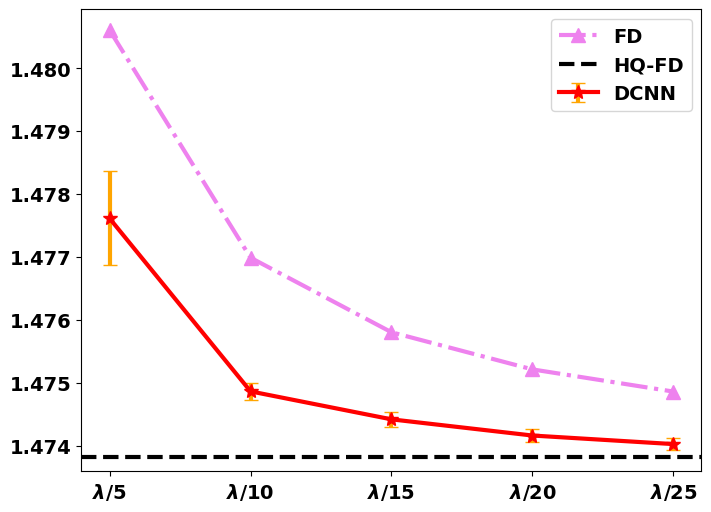

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(EIs_FD_1_TM[:5])), EIs_FD_1_TM[:5], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot')
plt.errorbar(np.arange(len(EIs_DCNN_1_TM)), EIs_DCNN_1_TM.mean(axis=1)[:, 0], label='DCNN', color='red', linewidth=3, marker='*', markersize=10,  yerr=EIs_DCNN_1_TM.std(axis=1)[:, 0], ecolor='orange', capsize=5, zorder=2)
plt.axhline(EIs_FD_1_TM[-1], color='black', linestyle='dashed', linewidth=3, label='HQ-FD')
plt.xticks([0, 1, 2, 3 ,4], [r'$\lambda$/5', r'$\lambda$/10', r'$\lambda$/15', r'$\lambda$/20', r'$\lambda$/25'])
plt.legend();

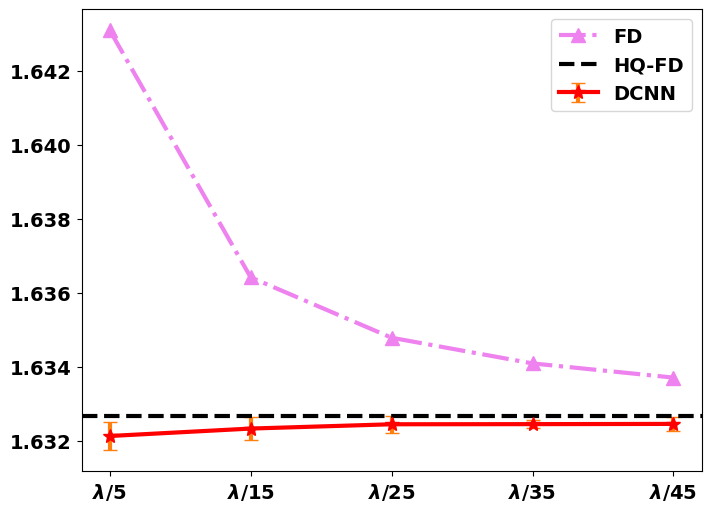

In [9]:
plt.figure(figsize=(8, 6))
plt.errorbar(np.arange(len(EIs_DCNN_2_TE)), EIs_DCNN_2_TE.mean(axis=1)[:, 0], label='DCNN', color='red', linewidth=3, marker='*', markersize=10,  yerr=EIs_DCNN_2_TE.std(axis=1)[:, 0], ecolor='tab:orange', capsize=5, zorder=2)
# plt.plot(np.arange(len(new_EIs_DCNN_2_TE_mean)), new_EIs_DCNN_2_TE_mean, label='DCNN', color='red', linewidth=3, marker='*', markersize=10)
plt.plot(np.arange(len(EIs_FD_2_TE[:5])), EIs_FD_2_TE[:5], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot')
# plt.plot(np.arange(len(EIs_FD_2_TE[:1])), [1.632199], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot')

plt.axhline(EIs_FD_2_TE[-1], color='black', linestyle='dashed', linewidth=3, label='HQ-FD')
plt.xticks([0, 1, 2, 3 ,4], [r'$\lambda$/5', r'$\lambda$/15', r'$\lambda$/25', r'$\lambda$/35', r'$\lambda$/45'])
plt.legend();

([<matplotlib.axis.XTick at 0x1cbc1b95400>,
 [Text(0, 0, '$\\lambda$/5'),
  Text(1, 0, '$\\lambda$/15'),
  Text(2, 0, '$\\lambda$/25'),
  Text(3, 0, '$\\lambda$/35'),
  Text(4, 0, '$\\lambda$/45')])

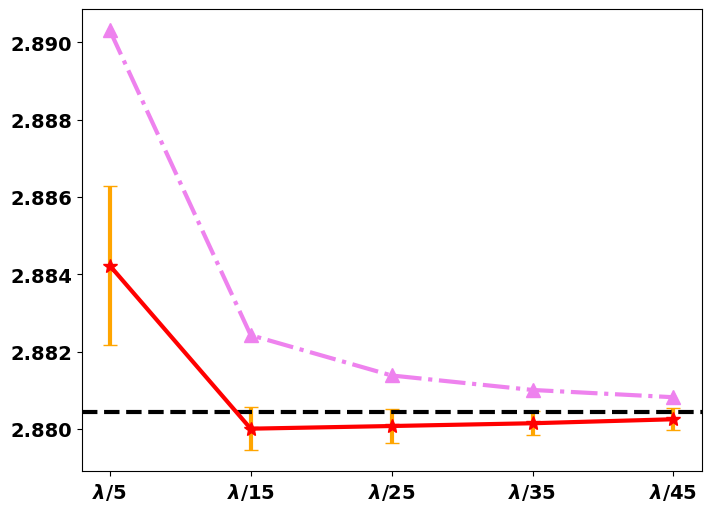

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(EIs_FD_3_TE[:5])), EIs_FD_3_TE[:5], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot')
# plt.plot(np.arange(len(EIs_DCNN_3_TE)), EIs_DCNN_3_TE, label='DCNN', color='red', linewidth=3, marker='*', markersize=10)
plt.errorbar(np.arange(len(EIs_DCNN_3_TE)), EIs_DCNN_3_TE.mean(axis=1)[:, 0], label='DCNN', color='red', linewidth=3, marker='*', markersize=10,  yerr=EIs_DCNN_3_TE.std(axis=1)[:, 0], ecolor='orange', capsize=5, zorder=2)

plt.axhline(EIs_FD_3_TE[-1], color='black', linestyle='dashed', linewidth=3, label='HQ-FD')
plt.xticks([0, 1, 2, 3 ,4], [r'$\lambda$/5', r'$\lambda$/15', r'$\lambda$/25', r'$\lambda$/35', r'$\lambda$/45'])

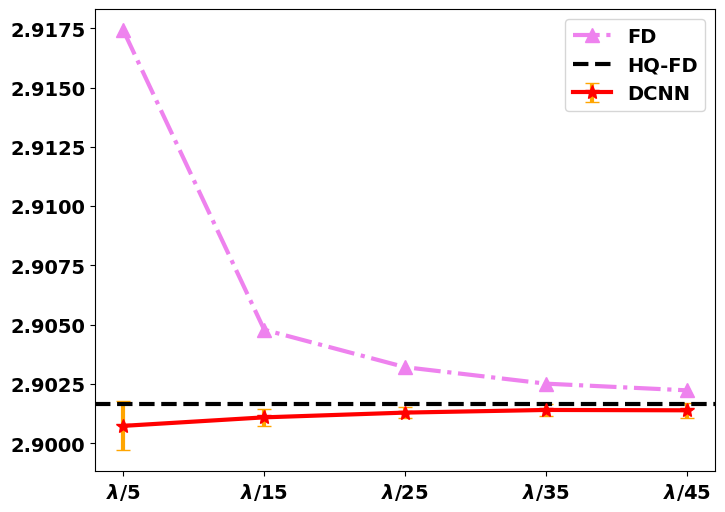

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(EIs_FD_3_TM[:5])), EIs_FD_3_TM[:5], label='FD', linewidth=3, color='violet', marker='^', markersize=10, linestyle='dashdot')
plt.errorbar(np.arange(len(EIs_DCNN_3_TM)), EIs_DCNN_3_TM.mean(axis=1)[:, 0], label='DCNN', color='red', linewidth=3, marker='*', markersize=10,  yerr=EIs_DCNN_3_TM.std(axis=1)[:, 0], ecolor='orange', capsize=5, zorder=2)
plt.axhline(EIs_FD_3_TM[-1], color='black', linestyle='dashed', linewidth=3, label='HQ-FD')

plt.xticks([0, 1, 2, 3 ,4], [r'$\lambda$/5', r'$\lambda$/15', r'$\lambda$/25', r'$\lambda$/35', r'$\lambda$/45'])
plt.legend();

# Numerical visualizatoin of the Cloesst convergence graph

Fitted parameters: a = 0.0602, b = -0.3967, c = -0.5210


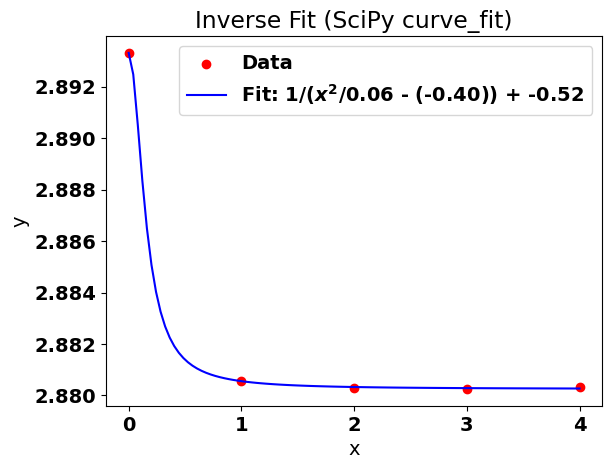

In [229]:
def multiplicative_inverse_function(x, a, b, c):
    """multiplicative inverse function: y = 1/(x/a - b)+ c"""
    return 1/((x**2)/a - b) + c

def fit_curve(x_data, y_data, candidate_fun = multiplicative_inverse_function):
    """
    Fits an exponential function y = a * exp(b * x) + c using SciPy's curve_fit.

    Args:
        x_data (array-like): Input x values.
        y_data (array-like): Corresponding y values.

    Returns:
        a_fit (float): Fitted parameter a.
        b_fit (float): Fitted parameter b.
        c_fit (float): Fitted parameter c.
    """
    y_mean = np.mean(y_data)
    y_std = np.std(y_data)
    y_scaled = (y_data - y_mean) / y_std  # Normalize y for numerical stability

    # Initial parameter guesses
    initial_params = [2, -1, 0.1]

    # Fit the exponential function
    popt, _ = curve_fit(candidate_fun, x_data, y_scaled, p0=initial_params)

    # Extract optimized parameters
    a_fit, b_fit, c_fit = popt

    # Rescale c to original y scale
    # c_fit = c_fit * y_std + y_mean
    # a_fit = a_fit * y_std  # Rescale a accordingly

    return a_fit, b_fit, c_fit

# Example data
x_data = np.delete(np.arange(len(EIs_DCNN_3_TE)), [])
y_data =np.delete(EIs_DCNN_3_TE, [])


# Fit the data
a_fit, b_fit, c_fit = fit_curve(x_data, y_data, multiplicative_inverse_function)
print(f"Fitted parameters: a = {a_fit:.4f}, b = {b_fit:.4f}, c = {c_fit:.4f}")

# Generate fitted curve
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit =multiplicative_inverse_function(x_fit, a_fit, b_fit, c_fit) * np.std(y_data) + np.mean(y_data)

# Plot results
plt.scatter(x_data, y_data, label="Data", color="red")
# plt.plot(x_fit, y_fit, label=f"Fit: {a_fit:.2f} * exp({b_fit:.2f} * x) + {c_fit:.2f}", color="blue")
plt.plot(x_fit, y_fit, label=f"Fit: 1/($x^2$/{a_fit:.2f} - ({b_fit:.2f})) + {c_fit:.2f}", color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Inverse Fit (SciPy curve_fit)")
plt.show()

In [230]:
multiplicative_inverse_function(4, a_fit, b_fit, c_fit) * np.std(y_data) + np.mean(y_data)


2.8802664654126278